# Why the structural scaffold matters

scHopfield does not fit the interaction matrix freely. Regulation is restricted to transcription
factors, and transcription-factor edges that an independent base network does not support are
penalized. That restriction is the least obvious part of the method, and the fair question is why
it is there at all: if the data can determine $W$, a prior can only get in the way.

This tutorial answers that by fitting the same velocity field both ways and measuring the
difference. The result is not that the unrestricted fit reproduces the data worse. **It
reproduces the data better.** What it cannot do is give the same answer twice.

**What you will do**

1. Measure how much independent variation the data actually contains.
2. Fit $W$ unrestricted and fit it scaffolded, on the same cells.
3. Score both on reproducing the velocity, and on agreeing with themselves across disjoint halves
   of the cells.
4. Watch the bias term absorb the model when nothing stops it.

**Runtime.** About a minute and a quarter on an RTX 3090, most of it in the four interaction
fits.

**One thing this tutorial cannot show.** The strongest evidence for the scaffold is a comparison
against a known ground-truth network, which needs simulated data whose true network is recorded.
That comparison is in the paper and is reproduced by the figure code shipped with the repository,
not here, because its simulation inputs are not part of this package. What is below is the
real-data half of the argument, and it runs from a public download.

## Setup: rebuild the object and load the fitted model

This tutorial starts from the checkpoint written by **Getting started**. Run that notebook first,
or copy its `pancreas_fitted.h5sch` next to this one.

The checkpoint holds the model and not the experiment: the interaction matrices, the bias and
degradation vectors, and the activation parameters. It does not hold the expression data, so the
cell-level object is rebuilt here from the same public download and the same recipe. That part
costs well under a minute and runs on a CPU. What it saves is the interaction fit, which is the
one step that wants a GPU.

The activation comes back with the network. `save_model` writes both Hill components of every
gene and the weight that mixes them, so `compute_sigmoid` after `load_model` rebuilds the
**two-component** activation the system was fitted with rather than a single Hill curve standing
in for it. Nothing is re-fitted here.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import scvelo as scv
import torch

import scHopfield as sch

scv.settings.verbosity = 0
sc.settings.verbosity = 0

CHECKPOINT = "pancreas_fitted.h5sch"
CLUSTER_KEY = "clusters"
ORDER = ["Ductal", "Ngn3 low EP", "Ngn3 high EP", "Pre-endocrine",
         "Alpha", "Beta", "Delta", "Epsilon"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"'{CHECKPOINT}' not found. Run the Getting started tutorial first: it fits the model "
        f"and writes this file.")

t0 = time.time()

# The same preparation as Getting started, section by section.
adata = scv.datasets.pancreas()
scv.pp.filter_genes(adata, min_shared_counts=20)
scv.pp.normalize_per_cell(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var["highly_variable"]].copy()
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.velocity(adata, mode="steady_state")

adata.layers["velocity_S"] = adata.layers["velocity"]
adata.var["gamma"] = adata.var["velocity_gamma"].astype(np.float32)
vel = np.asarray(adata.layers["velocity_S"])
keep = (np.isfinite(adata.var["gamma"].values)
        & np.isfinite(vel).all(axis=0)
        & (adata.var["gamma"].values > 0))
adata = adata[:, keep].copy()
adata.var["scHopfield_used"] = True

# Restore the fitted system from the checkpoint: the network and the activation both.
adata = sch.tl.load_model(adata, CHECKPOINT)
sch.pp.compute_sigmoid(adata, spliced_key="Ms")

print(f"setup: {time.time() - t0:.1f} s on a CPU")
print(adata.shape)
print("fitted systems:", sorted(k[2:] for k in adata.varp if k.startswith("W_")))

/tmp/ipykernel_4005814/2386655385.py:36: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
.../site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


Model loaded from 'pancreas_fitted.h5sch'  |  clusters=['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']  |  genes=2000


setup: 13.3 s on a CPU
(3696, 2000)
fitted systems: ['Alpha', 'Beta', 'Delta', 'Ductal', 'Epsilon', 'Ngn3 high EP', 'Ngn3 low EP', 'Pre-endocrine', 'all']


The checkpoint and the rebuild have to describe the same genes in the same order, or the model
would be loaded onto the wrong ones. `load_model` raises if a gene the model needs is absent, and
warns if the file predates the activation being stored in full. Neither fires above, so the
activation in use is the fitted one, and it is worth seeing how much of it is genuinely
two-component.

In [2]:
n_bimodal = int((adata.var["sigmoid_mix"].values < 1 - 1e-9).sum())
print(f"activation fitted with two components: {adata.uns['scHopfield']['sigmoid_bimodal']}")
print(f"genes with a real second activation component: {n_bimodal} / {adata.n_vars}")

activation fitted with two components: True
genes with a real second activation component: 586 / 2000


## 1. How much independent variation is there?

An unrestricted $W$ gives every gene one free coefficient per possible regulator, so fitting 2000
genes means 2000 free numbers per gene. The question is how many genuinely independent directions
the data offers against that.

The relevant matrix is not the expression matrix but the **activation** matrix $\sigma(X)$, since
that is what multiplies $W$. Its effective rank is measured here as a participation ratio over its
singular values, which reports an effective number of directions in units of genes without
requiring a cutoff.

In [3]:
def participation_ratio(M):
    # Effective rank of M, as a participation ratio over its singular values.
    s = np.linalg.svd(M, compute_uv=False)
    s = s[s > 1e-9]
    return float((s.sum() ** 2) / (np.sum(s ** 2) + 1e-12))


sigma_X = np.asarray(adata.layers["sigmoid"])
n_genes = adata.n_vars

rows = [{"cells": adata.n_obs,
         "effective directions": participation_ratio(sigma_X),
         "population": "all cells"}]
for c in ORDER:
    m = (adata.obs[CLUSTER_KEY].astype(str) == c).values
    rows.append({"population": c, "cells": int(m.sum()),
                 "effective directions": participation_ratio(sigma_X[m])})

eff = pd.DataFrame(rows).set_index("population")
eff["as a fraction of the genes"] = eff["effective directions"] / n_genes
print(f"genes being fit: {n_genes}\n")
eff.round({"effective directions": 1, "as a fraction of the genes": 4})

genes being fit: 2000



,cells,effective directions,as a fraction of the genes
population,,,
all cells,3696,220.8,0.1104
Ductal,916,102.8,0.0514
Ngn3 low EP,262,49.0,0.0245
Ngn3 high EP,642,72.7,0.0364
Pre-endocrine,592,68.1,0.0340
Alpha,481,56.0,0.0280
Beta,591,61.8,0.0309
Delta,70,9.9,0.0049
Epsilon,142,19.5,0.0097


Every cell type offers a few percent of the directions that an unrestricted $W$ has parameters
for. This is not a shortage of cells that more sequencing would fix. It is that cells of one type
are similar to one another, which is what makes them a type: their activation profiles lie close
to a low-dimensional set, so they cannot pin down a matrix defined over the full gene space.

That is the whole problem in one number. What follows measures its consequence.

## 2. Fitting the same data two ways

One cell type, split at random into two disjoint halves. Each half is fit independently, and the
two answers are compared. A fit that the data determines gives nearly the same $W$ on both halves.
A fit that the data does not determine gives two different matrices that both explain the data.

The unrestricted arm is a plain least-squares solve of

$$v + \gamma x = \sigma(x)\,W^{\top} + \text{const}$$

at a single fixed $\gamma$, with no scaffold, no bias penalty and no boundedness term. It is
deliberately **not** a version of the published configuration. It is the contrast to it: what
velocity alone determines.

In [4]:
CLUSTER = "Ductal"
GAMMA_FIXED = 0.1

cells = np.where((adata.obs[CLUSTER_KEY].astype(str) == CLUSTER).values)[0]
rng = np.random.default_rng(0)
rng.shuffle(cells)
half_a, half_b = cells[:len(cells) // 2], cells[len(cells) // 2:]
print(f"{CLUSTER}: {len(half_a)} and {len(half_b)} cells, "
      f"{n_genes} free regulators per gene")

S = np.asarray(adata.layers["sigmoid"])
V = np.asarray(adata.layers["velocity_S"])
X = np.asarray(adata.layers["Ms"])


def fit_unrestricted(idx):
    design = np.hstack([S[idx], np.ones((len(idx), 1))])
    return np.linalg.lstsq(design, V[idx] + GAMMA_FIXED * X[idx], rcond=None)[0][:-1].T


def off_diagonal(W):
    return W[~np.eye(W.shape[0], dtype=bool)]


t0 = time.time()
W_free_a, W_free_b = fit_unrestricted(half_a), fit_unrestricted(half_b)
print(f"unrestricted least squares, both halves: {time.time() - t0:.1f} s")

Ductal: 458 and 458 cells, 2000 free regulators per gene


unrestricted least squares, both halves: 0.9 s


In [5]:
t0 = time.time()
base = sch.fetch_base_grn("mouse")
scaffold, n_tfs, n_edges = sch.inf.build_scaffold(adata, base, return_stats=True)
print(f"scaffold: {n_tfs} TFs, {n_edges} edges\n")

W_scaffolded, scaffolded_params = [], []
for idx in (half_a, half_b):
    part = adata[idx].copy()
    part.var["scHopfield_used"] = True
    sch.inf.fit_interactions(part, cluster_key=CLUSTER_KEY, w_scaffold=scaffold.values.T,
                             device=DEVICE, include_neighbors=False, seed=0)
    W_scaffolded.append(np.asarray(part.varp[f"W_{CLUSTER}"]))
    scaffolded_params.append((np.asarray(part.varp[f"W_{CLUSTER}"]),
                              np.asarray(part.var[f"I_{CLUSTER}"]),
                              np.asarray(part.var[f"gamma_{CLUSTER}"])))
print(f"\nscaffolded fits, both halves: {time.time() - t0:.1f} s")

scaffold: 105 TFs, 87632 edges

Inferring interaction matrix W and bias vector I for cluster Ductal


Training Epochs:   0%|          | 0/600 [00:00<?, ?it/s]

Training Epochs:   0%|          | 0/600 [00:00<?, ?it/s]

Training Epochs:   0%|          | 1/600 [00:00<01:52,  5.33it/s]

Training Epochs:   2%|▏         | 10/600 [00:00<00:14, 41.06it/s]

...

Training Epochs:  98%|█████████▊| 587/600 [00:06<00:00, 85.80it/s]

Training Epochs:  99%|█████████▉| 596/600 [00:06<00:00, 85.69it/s]

Training Epochs:  99%|█████████▉| 596/600 [00:06<00:00, 85.69it/s]

Training Epochs: 100%|██████████| 600/600 [00:06<00:00, 86.72it/s]

[Epoch 600/600] Total Loss: 1.877022, Reconstruction Loss: 1.798980, LR: 1.00e-05, Batch size: 128

scaffolded fits, both halves: 36.4 s


Now score both arms on the two things that matter, using each half's own fit.

In [6]:
def row_cosine(A, B):
    n = np.linalg.norm(A, axis=1) * np.linalg.norm(B, axis=1)
    return (A * B).sum(1) / np.where(n > 0, n, np.nan)


split_free = np.corrcoef(off_diagonal(W_free_a), off_diagonal(W_free_b))[0, 1]
split_scaf = np.corrcoef(off_diagonal(W_scaffolded[0]), off_diagonal(W_scaffolded[1]))[0, 1]

recon_free_in = np.nanmedian(row_cosine(S[half_a] @ W_free_a.T - GAMMA_FIXED * X[half_a], V[half_a]))
recon_free_out = np.nanmedian(row_cosine(S[half_b] @ W_free_a.T - GAMMA_FIXED * X[half_b], V[half_b]))

W_s, I_s, gamma_s = scaffolded_params[0]
recon_scaf_in = np.nanmedian(row_cosine(S[half_a] @ W_s.T + I_s - gamma_s * X[half_a], V[half_a]))
recon_scaf_out = np.nanmedian(row_cosine(S[half_b] @ W_s.T + I_s - gamma_s * X[half_b], V[half_b]))

summary = pd.DataFrame({
    "unrestricted": {
        "split-half correlation of W": split_free,
        "velocity cosine, cells it was fit on": recon_free_in,
        "velocity cosine, the other half": recon_free_out,
        "fraction of W that is nonzero": float(np.mean(np.abs(W_free_a) > 1e-8)),
    },
    "scaffolded": {
        "split-half correlation of W": split_scaf,
        "velocity cosine, cells it was fit on": recon_scaf_in,
        "velocity cosine, the other half": recon_scaf_out,
        "fraction of W that is nonzero": float(np.mean(np.abs(W_scaffolded[0]) > 1e-8)),
    },
})
summary.round(4)

,unrestricted,scaffolded
split-half correlation of W,0.3466,0.8586
"velocity cosine, cells it was fit on",1.0000,0.9904
"velocity cosine, the other half",0.9940,0.9877
fraction of W that is nonzero,0.9630,0.0363


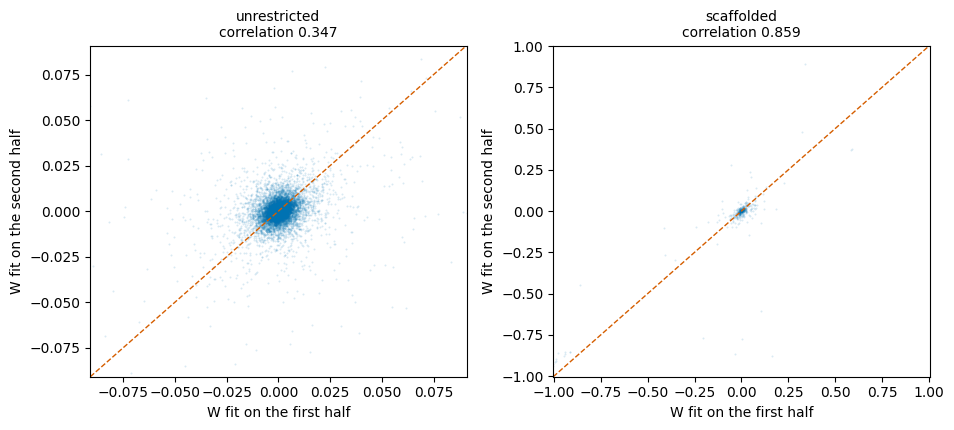

In [7]:
rng_plot = np.random.default_rng(1)
pick = rng_plot.choice(off_diagonal(W_free_a).size, 20000, replace=False)

fig, axs = plt.subplots(1, 2, figsize=(9.6, 4.4), sharex=False)
for ax, (Wa, Wb, label, r) in zip(axs, [
        (W_free_a, W_free_b, "unrestricted", split_free),
        (W_scaffolded[0], W_scaffolded[1], "scaffolded", split_scaf)]):
    xa, xb = off_diagonal(Wa)[pick], off_diagonal(Wb)[pick]
    ax.scatter(xa, xb, s=2, alpha=0.15, color="#0072B2", linewidths=0)
    lim = np.percentile(np.abs(np.concatenate([xa, xb])), 99.9)
    ax.plot([-lim, lim], [-lim, lim], color="#D55E00", lw=1, ls="--")
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel("W fit on the first half")
    ax.set_ylabel("W fit on the second half")
    ax.set_title(f"{label}\ncorrelation {r:.3f}", fontsize=10)
fig.tight_layout()
plt.show()

Each point is one off-diagonal entry of the interaction matrix, placed by what the two independent
halves of the same cell type say about it. A determined parameter sits on the diagonal. The
unrestricted cloud is round, which is what an undetermined parameter looks like.

Read the first row against the second.

The unrestricted fit reconstructs the velocity of the cells it was fit on **essentially
perfectly**, and it still does well on the held-out half. By the only criterion a velocity method
offers, it is the better model. But its interaction matrix agrees with itself far more weakly
across the two halves than the scaffolded one does, and it fills almost every entry of $W$ while
the scaffolded fit uses a few percent of them.

Two matrices that differ this much cannot both be the regulatory network. They are two points in a
large set of matrices that all reproduce the same motion, and least squares returns whichever one
its particular sample happens to select. Reconstructing the velocity is simply not evidence that
the interactions are right, which is why the paper's structural claims are not argued from
reconstruction quality.

The scaffold does not add information the data lacks. It removes the freedom the data cannot pay
for, and the answer stops moving.

## 3. The bias term, when nothing stops it

There is a second degeneracy, and it is easy to miss because it does not show up in the
reconstruction either. The model has a constant drive $I$, and a constant can absorb a great deal
of the dynamics if it is allowed to. When it does, the interaction matrix stops carrying the
explanation, and the energy landscape stops meaning what it appears to mean.

Two fits of the same cells: the published configuration, with a scaffold and an L1 penalty on $I$,
against one with neither. Both are scored by how much of the energy the bias term accounts for.

In [8]:
def energy_shares(part):
    sch.pp.compute_sigmoid(part, spliced_key="Ms")
    sch.tl.compute_energies(part, cluster_key=CLUSTER_KEY)
    e = part.obs[["energy_interaction", "energy_degradation", "energy_bias"]].abs().mean()
    return e / e.sum()


arms = {}
for label, kwargs in [
        ("scaffold and bias penalty", dict(w_scaffold=scaffold.values.T, bias_regularization=1)),
        ("neither", dict(w_scaffold=None, bias_regularization=0, only_TFs=False)),
]:
    part = adata[half_a].copy()
    part.var["scHopfield_used"] = True
    t0 = time.time()
    sch.inf.fit_interactions(part, cluster_key=CLUSTER_KEY, device=DEVICE,
                             include_neighbors=False, seed=0, **kwargs)
    arms[label] = energy_shares(part)
    I = np.asarray(part.var[f"I_{CLUSTER}"])
    print(f"{label:26s} nonzero entries of I: {np.count_nonzero(I):5d} / {len(I)}   "
          f"({time.time() - t0:.0f} s)")

shares = pd.DataFrame(arms).T
shares.columns = ["interaction", "degradation", "bias"]
shares.round(4)

Inferring interaction matrix W and bias vector I for cluster Ductal


Training Epochs:   0%|          | 0/600 [00:00<?, ?it/s]

Training Epochs:   0%|          | 0/600 [00:00<?, ?it/s]

Training Epochs:   2%|▏         | 9/600 [00:00<00:06, 84.95it/s]

[Epoch 1/600] Total Loss: 4218.416829, Reconstruction Loss: 235.002960, LR: 1.00e-01, Batch size: 128


...

[Epoch 600/600] Total Loss: 2.444446, Reconstruction Loss: 1.722835, LR: 1.00e-04, Batch size: 128


scaffold and bias penalty  nonzero entries of I:   965 / 2000   (18 s)
Inferring interaction matrix W and bias vector I for cluster Ductal


Inferring interaction matrix W and bias vector I for cluster all


neither                    nonzero entries of I:  1923 / 2000   (5 s)


,interaction,degradation,bias
scaffold and bias penalty,0.3594,0.6406,0.0000
neither,0.0372,0.0429,0.9199


With the scaffold and the penalty in place, the bias contributes essentially none of the energy:
the interaction and degradation terms account for the model, which is what makes the energy
landscape a statement about regulation. Remove both and the bias takes a share of the explanation
that the interactions should be carrying.

This is why the two restrictions are described together. A scaffold on $W$ without a penalty on
$I$ moves the degeneracy rather than removing it.

## What to take from this

- The data does not determine an unrestricted interaction matrix, and it says so through
  reproducibility rather than through fit quality.
- Reconstruction accuracy is not evidence about network structure. The unrestricted fit wins on
  reconstruction and loses on everything else.
- The restrictions are what make the fitted matrix and the energy landscape mean what they claim
  to mean.

## Where to go next

- **Reading the fitted system** uses the restricted fit to derive the energy, stability and
  network views.
- **Ground-truth circuits** does the complementary experiment, where the true $W$ is known exactly
  and recovery can be scored directly.